<a href="https://colab.research.google.com/github/TejasKayarkar03/Machine-Vision-CM45/blob/main/MV_Pr4_CM23045_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Saving photo-1755926175481-cd6ebe52d7f0.avif to photo-1755926175481-cd6ebe52d7f0 (1).avif


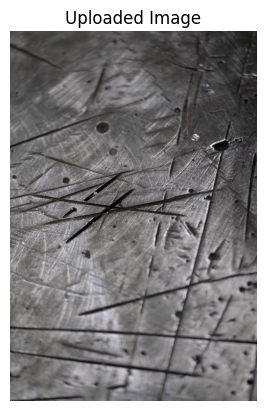

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload image manually
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.imshow(rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

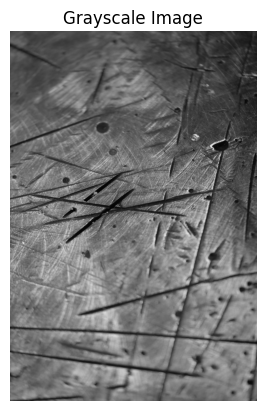

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

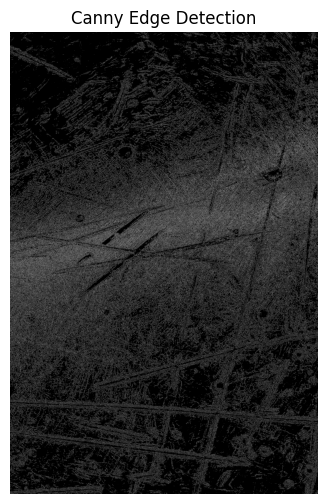

In [ ]:
edges = cv2.Canny(blur, 10, 10)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

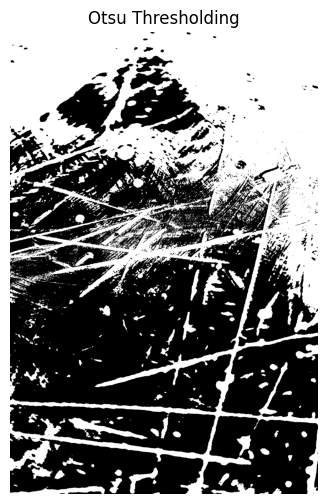

In [ ]:
 _, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis("off")
plt.show()

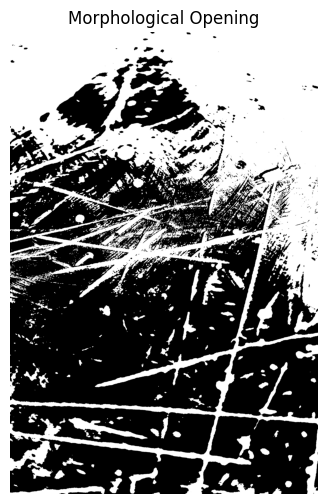

In [ ]:
kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

plt.figure(figsize=(6,6))
plt.imshow(opening, cmap='gray')
plt.title("Morphological Opening")
plt.axis("off")
plt.show()

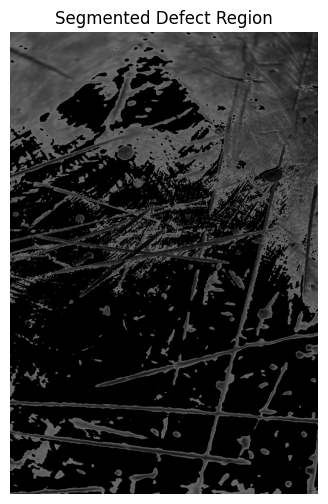

In [ ]:
segmented = cv2.bitwise_and(gray, gray, mask=closing)

plt.figure(figsize=(6,6))
plt.imshow(segmented, cmap='gray')
plt.title("Segmented Defect Region")
plt.axis("off")
plt.show()

In [ ]:
contours, _ = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total Contours Found:", len(contours))

Total Contours Found: 793


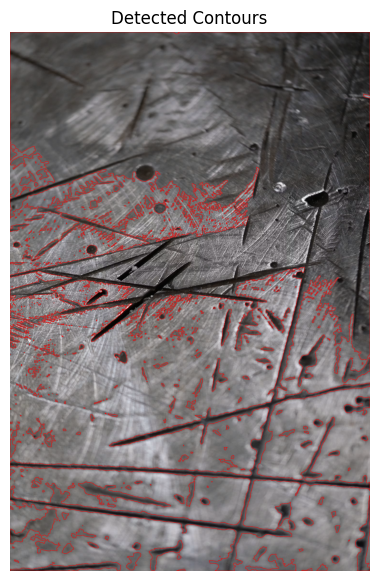

In [ ]:
contour_img = rgb.copy()

cv2.drawContours(
    contour_img,
    contours,
    -1,
    (255,0,0),
    2
)

plt.figure(figsize=(7,7))
plt.imshow(contour_img)
plt.title("Detected Contours")
plt.axis("off")
plt.show()

Detected Defects: 537


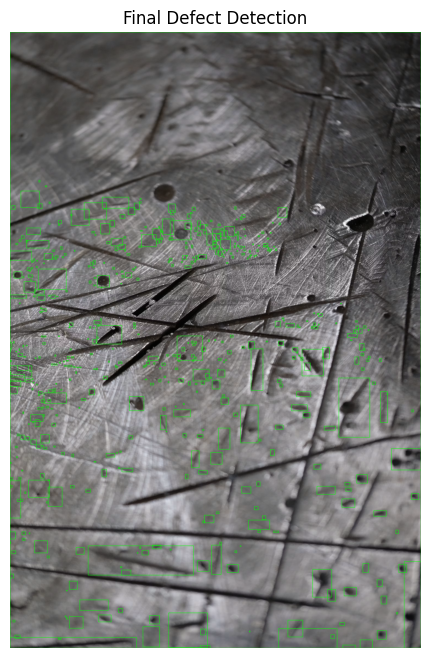

In [ ]:
result = rgb.copy()

count = 0

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 20:
        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(
            result,
            (x, y),
            (x+w, y+h),
            (0,255,0),
            2
        )

        count += 1

print("Detected Defects:", count)

plt.figure(figsize=(8,8))
plt.imshow(result)
plt.title("Final Defect Detection")
plt.axis("off")
plt.show()

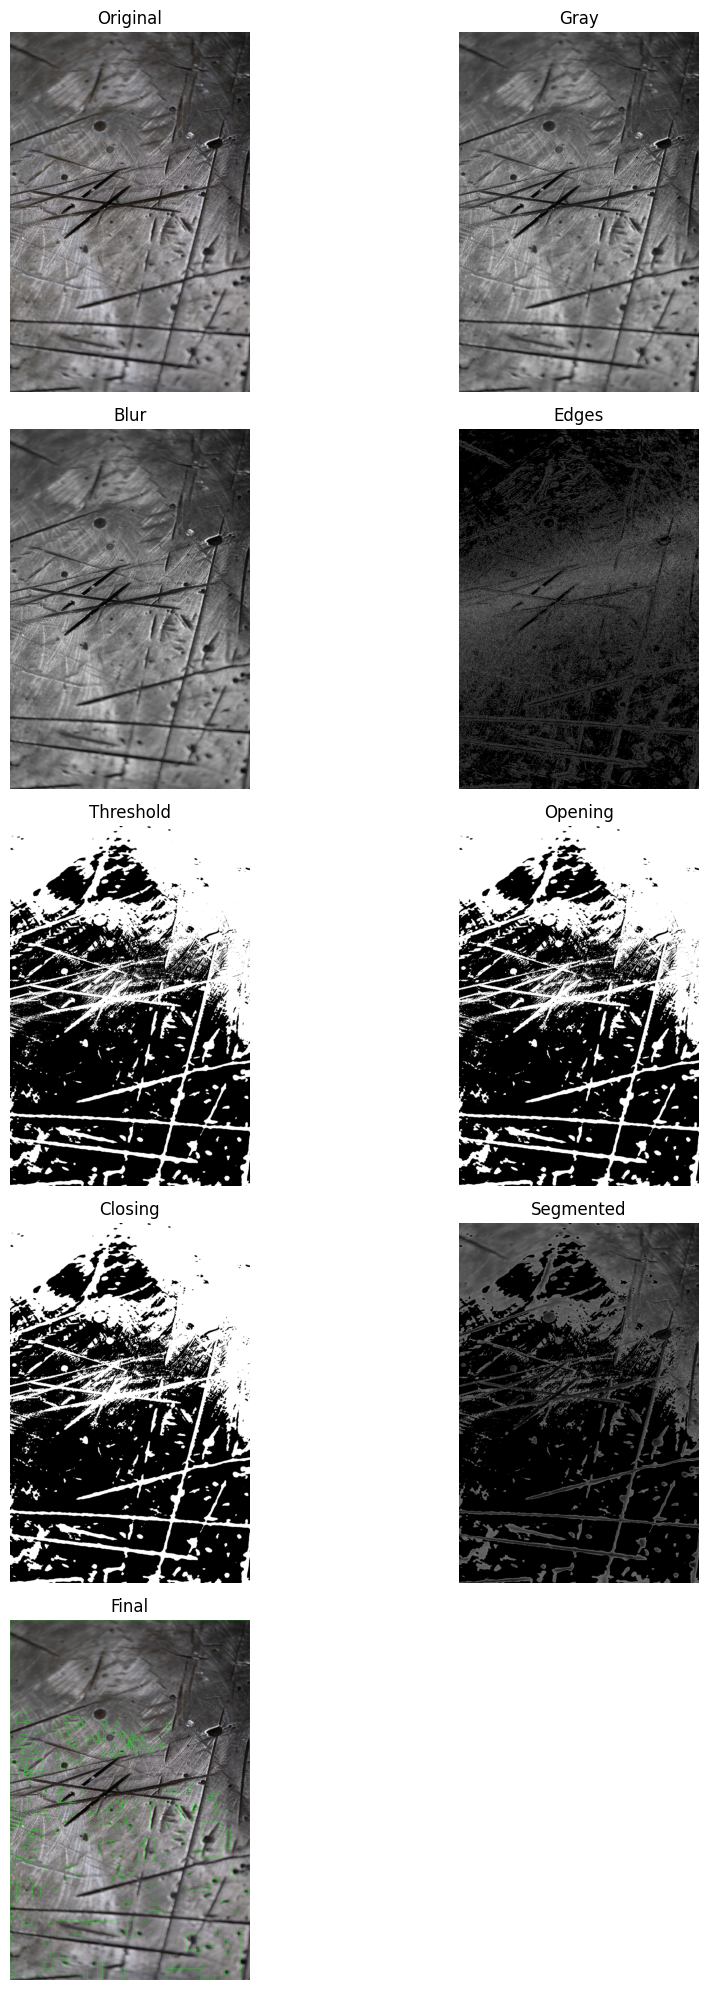

In [ ]:
titles = [
    "Original",
    "Gray",
    "Blur",
    "Edges",
    "Threshold",
    "Opening",
    "Closing",
    "Segmented",
    "Final"
]

images = [
    rgb,
    gray,
    blur,
    edges,
    thresh,
    opening,
    closing,
    segmented,
    result
]

plt.figure(figsize=(10, 20))  # Width, Height

for i in range(len(images)):
    plt.subplot((len(images)+1)//2, 2, i+1)  # 2 columns

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()